# EMCF: connect acquisitions before unwrapping space

What extra consistency is supplied by a triangle of acquisition pairs?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

For acquisition phases $\phi_0,\phi_1,\phi_2$, pair differences obey
$(\phi_1-\phi_0)+(\phi_2-\phi_1)-(\phi_2-\phi_0)=0$.
Wrapped measurements can differ from this relation by whole turns.

EMCF uses temporal loops of **spatial edge measurements**. For temporal loop
signs $s_{cj}$, corrections satisfy $\sum_j s_{cj}k_j=-r_c$.

1. Specify acquisition pairs as links (earlier, later).
2. Form interferograms, or supply them directly in link order.
3. Correct temporal loop discrepancies for every spatial edge.
4. Run the spatial correction stage for each interferogram and integrate.

The two stages enforce their own constraints. Do not infer that the final
spatial stage automatically certifies every possible joint space-time objective.

Wrapped pair measurements: [ 2.5         2.5        -1.28318531]
Triangle circulation in turns: 1.0


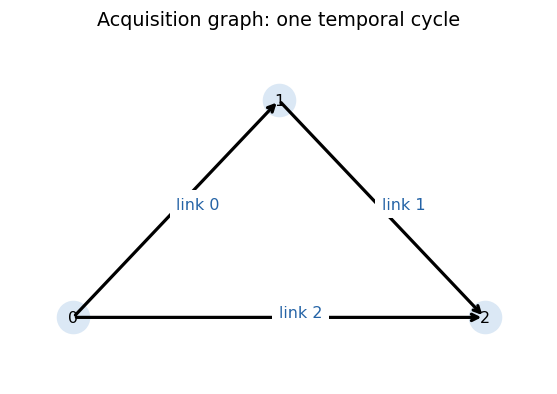

In [2]:
links=np.array([[0,1],[1,2],[0,2]])
history=np.array([0.,2.5,5.])
pair=W(history[links[:,1]]-history[links[:,0]])
print('Wrapped pair measurements:',pair)
print('Triangle circulation in turns:',(pair[0]+pair[1]-pair[2])/(2*np.pi))
fig,ax=plt.subplots(figsize=(6,4)); pos=np.array([[0,0],[1,1],[2,0]])
for j,(a,b) in enumerate(links):
    ax.annotate('',xy=pos[b],xytext=pos[a],arrowprops=dict(arrowstyle='->',lw=2))
    middle=(pos[a]+pos[b])/2; ax.text(*middle,f'link {j}',color='#2463a6',bbox=dict(facecolor='white',edgecolor='none'))
for i,p in enumerate(pos): ax.scatter(*p,s=400,color='#dbe8f5'); ax.text(*p,str(i),ha='center',va='center')
ax.set(xlim=(-.3,2.3),ylim=(-.3,1.3),title='Acquisition graph: one temporal cycle'); ax.axis('off'); plt.show()

## 2 · Read the calculation

The triangle is acquisition geometry, not three neighboring image pixels.
For the full algorithm each spatial edge supplies its own vector across these
links. `emcf_unwrap` takes acquisition phases; `emcf_unwrap_interferograms`
takes already-formed pair measurements. Both return one image per link.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

EmcfInfo(backend='emcf-flow', network='links', mode='stack', shape=(6, 7), epochs=3, interferograms=3, pixels=42, nodes=42, edges=71, cycles=1, temporal_solves=0, temporal_residues=0, temporal_turns=0, residues=0, components=1, max_jump=0, objective=0.0, objective_per_interferogram=array([0., 0., 0.]), augmentations=0, proven=True)


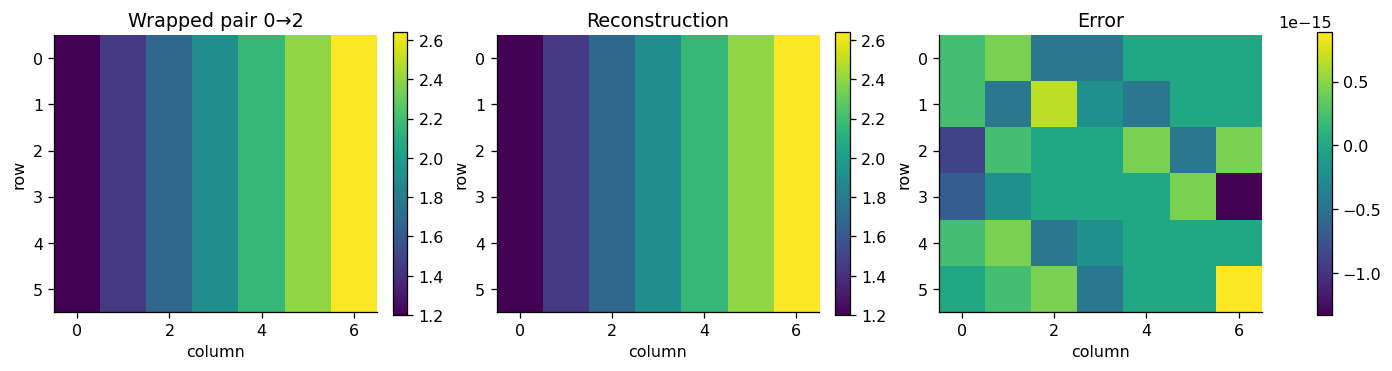

In [3]:
y,x=np.mgrid[0:6,0:7]
acquisition_truth=np.array([(.3+.12*i)*x+.2*y+.6*i for i in range(3)])
acquisitions=W(acquisition_truth)
pair_truth=acquisition_truth[links[:,1]]-acquisition_truth[links[:,0]]
pair_phase=W(acquisitions[links[:,1]]-acquisitions[links[:,0]])
u,info=pv.emcf_unwrap(acquisitions,links=links,return_info=True)
print(info); assert u.shape==pair_truth.shape
images([pair_phase[2],align(u[2],pair_truth[2]),align(u[2],pair_truth[2])-pair_truth[2]],
       ['Wrapped pair 0→2','Reconstruction','Error'])

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

| Link | Aligned RMSE |
|---|---|
| (0, 1) | 4.328e-16 |
| (1, 2) | 4.411e-16 |
| (0, 2) | 4.128e-16 |

Both input APIs agree on the same pair measurements.


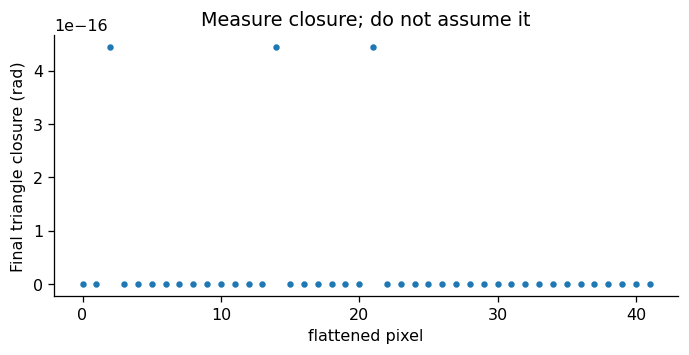

In [4]:
v,info=pv.emcf_unwrap_interferograms(pair_phase,links,return_info=True)
assert np.allclose(u,v)
table(['Link','Aligned RMSE'],[(str(tuple(link)),f'{pv.rmse_aligned(a,b):.3e}')
                            for link,a,b in zip(links,u,pair_truth)])
print('Both input APIs agree on the same pair measurements.')
fig,ax=plt.subplots(figsize=(7,3))
closure=u[0]+u[1]-u[2]; ax.plot(closure.ravel(),'o',ms=3)
ax.set(xlabel='flattened pixel',ylabel='Final triangle closure (rad)',title='Measure closure; do not assume it'); plt.show()

## 5 · Interpretation and limits

Default links require at least four acquisitions; the three-epoch example
therefore supplies explicit links. Pair order determines signs. A mask and
weight have the shape of one spatial image, not the acquisition stack.
This clean example validates the two API routes but is not a noisy-scene benchmark.
Individual interferograms retain separate offset conventions; measure temporal
closure after processing if your downstream analysis requires it.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`emcf.py`](../src/parvaneh/emcf.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.